IMPORTS 

In [1]:
#DataSet Loader and extracts the zip

import os 
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    make_scorer
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
#File Check for Data is located on device to work
#Loads our Dataset 
from pathlib import Path
import zipfile

REQUIRED = ["train.csv", "test.csv", "greeks.csv", "sample_submission.csv"]

def has_required_files(folder):
    folder = Path(folder)
    return folder.exists() and all ((folder / file).exists() for file in REQUIRED)

def find_dataset_folder():
    current_dir = Path.cwd()

    possible_folders = [
        current_dir,
        current_dir / "data",
        current_dir / "icr_data",
        current_dir / "icr-identify-age-related-conditions",
        Path("/kaggle/input/icr-identify-age-related-conditions"),
        Path("/mnt/data/icr_data"),
        Path("/content/icr_data"),
    ]
    
    for folder in possible_folders:
        if has_required_files(folder):
            return Path(folder)

    possible_zip_locations = [
        current_dir,
        current_dir / "data",
        Path("/mnt/data"),
        Path("/content"),
    ]

    zip_candidates = []
    for folder in possible_zip_locations:
        if folder.exists():
            zip_candidates.extend(folder.glob("*icr*age*related*conditions*.zip"))
            zip_candidates.extend(folder.glob("icr*.zip"))

    zip_candidates = list(dict.fromkeys(zip_candidates))

    if zip_candidates:
        zip_path = zip_candidates[0]
        extract_path = current_dir / "icr_data"
        extract_path.mkdir(exist_ok=True)

        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(extract_path)

        if has_required_files(extract_path):
            return extract_path

    raise FileNotFoundError("Dataset Not Found")    


DATA_DIR = find_dataset_folder()

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
greeks = pd.read_csv(DATA_DIR / "greeks.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print("\nDataset Shapes:")
print("train Shape:", train.shape)
print("test Shape:", test.shape)
print("Greeks Shape:", greeks.shape)
print("Sample Submission Shape:", sample_submission.shape)

train.head()


Dataset Shapes:
train Shape: (617, 58)
test Shape: (5, 57)
Greeks Shape: (617, 6)
Sample Submission Shape: (5, 3)


,Id,AB,AF,AH,AM,AR,AX,AY,AZ,BC,...,FL,FR,FS,GB,GE,GF,GH,GI,GL,Class
0,000ff2bfdfe9,0.209377,3109.03329,85.200147,22.394407,8.138688,0.699861,0.025578,9.812214,5.555634,...,7.298162,1.73855,0.094822,11.339138,72.611063,2003.810319,22.136229,69.834944,0.120343,1
1,007255e47698,0.145282,978.76416,85.200147,36.968889,8.138688,3.632190,0.025578,13.517790,1.229900,...,0.173229,0.49706,0.568932,9.292698,72.611063,27981.562750,29.135430,32.131996,21.978000,0
2,013f2bd269f5,0.470030,2635.10654,85.200147,32.360553,8.138688,6.732840,0.025578,12.824570,1.229900,...,7.709560,0.97556,1.198821,37.077772,88.609437,13676.957810,28.022851,35.192676,0.196941,0
3,043ac50845d5,0.252107,3819.65177,120.201618,77.112203,8.138688,3.685344,0.025578,11.053708,1.229900,...,6.122162,0.49706,0.284466,18.529584,82.416803,2094.262452,39.948656,90.493248,0.155829,0
4,044fb8a146ec,0.380297,3733.04844,85.200147,14.103738,8.138688,3.942255,0.054810,3.396778,102.151980,...,8.153058,48.50134,0.121914,16.408728,146.109943,8524.370502,45.381316,36.262628,0.096614,1


In [3]:
#Checks the Dataset for examples of Class 0 and 1
#Assists in prediction for the model's accuracy
#Data Check of class balance, missing values and feature types

print("Target Distribution:")
print(train["Class"].value_counts())
print()

print("Target Disribution Percentage:")
print(train["Class"].value_counts(normalize=True))
print()

print("Feature Data Types:")

print(train.dtypes.value_counts())
print()

missing_values = train.isna().sum().sort_values(ascending=False)
print("Top Missing Value Columns:")
print(missing_values[missing_values > 0].head(15))

Target Distribution:
Class
0    509
1    108
Name: count, dtype: int64

Target Disribution Percentage:
Class
0    0.824959
1    0.175041
Name: proportion, dtype: float64

Feature Data Types:
float64    55
object      2
int64       1
Name: count, dtype: int64

Top Missing Value Columns:
BQ    60
EL    60
CC     3
CB     2
FS     2
FC     1
DU     1
FL     1
GL     1
dtype: int64


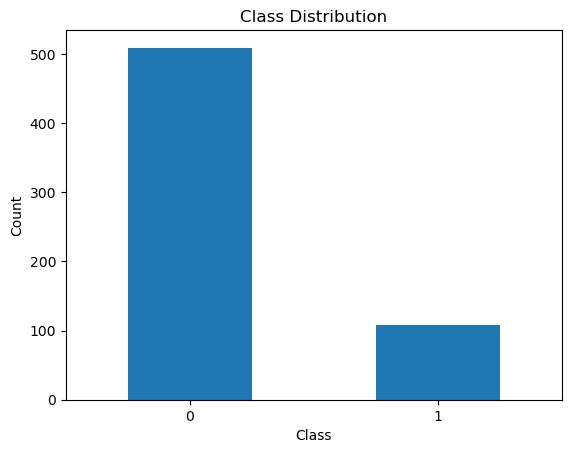

In [4]:
#Separates features and targer

train["Class"].value_counts().sort_index().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [5]:
#Data Overivew
X = train.drop(columns=["Class"])
y = train["Class"]

test_ids = test["Id"].copy()

X_model = X.drop(columns=["Id"])
test_model = test.drop(columns=["Id"])

numeric_features = X_model.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_model.select_dtypes(include=["object"]).columns.tolist()

print("# of numeric features:", len(numeric_features))
print("Categorical Features:", categorical_features)

# of numeric features: 55
Categorical Features: ['EJ']


In [6]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [7]:
#Evaluating Log loss for evaluation
def balanced_log_loss(y_true, y_pred_proba):
    y_true = np.asarray(y_true)
    y_pred_proba = np.asarray(y_pred_proba)

    eps = 1e-15
    y_pred_proba = np.clip(y_pred_proba, eps, 1 - eps)

    n0 = np.sum(y_true == 0)
    n1 = np.sum(y_true == 1)

    loss0 = -np.sum((y_true == 0) * np.log(y_pred_proba[:, 0])) / n0
    loss1 = -np.sum((y_true == 1) * np.log(y_pred_proba[:, 1])) / n1

    return (loss0 + loss1) / 2

def negative_balanced_log_loss_scorer(estimator, X_val, y_val):
    pred_proba = estimator.predict_proba(X_val)
    return -balanced_log_loss(y_val, pred_proba)

In [8]:
#Cross validation for balanced splits
cv = StratifiedKFold (
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [9]:
#Change this to False when wanting to run a bigger sample
#Current on True for a quick test that's all

FAST_MODE = True
print("Fast mode:", FAST_MODE)

Fast mode: True


In [10]:
def evaluate_model_cv(model_name, model, X_data, y_data, cv):
    print("=" * 80)
    print(model_name)
    print("=" * 80)

    oof_proba = cross_val_predict(
        model,
        X_data,
        y_data,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )

    oof_pred = np.argmax(oof_proba, axis=1)

    standard_ll = log_loss(y_data, oof_proba)
    balanced_ll = balanced_log_loss(y_data, oof_proba)
    acc = accuracy_score(y_data, oof_pred)

    print(f"Accuracy: {acc:.4f}")
    print(f"Log Loss: {standard_ll:.4f}")
    print(f"Balanced Log Loss: {balanced_ll:.4f}")
    print()
    print("Classifciation Report")
    print(classification_report(y_data, oof_pred))

    cm = confusion_matrix(y_data, oof_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    disp.plot()
    plt.title(f"Confusion MAtrix: {model_name}")
    plt.show()

    return {
        "model_name": model_name,
        "accuracy": acc,   
        "log_loss": standard_ll,
        "balanced_log_loss": balanced_ll,
        "oof_proba": oof_proba,
        "oof_pred": oof_pred
    }

Logistic Regression Baseline
Accuracy: 0.8849
Log Loss: 0.4307
Balanced Log Loss: 0.6215

Classifciation Report
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       509
           1       0.64      0.81      0.71       108

    accuracy                           0.88       617
   macro avg       0.80      0.85      0.82       617
weighted avg       0.90      0.88      0.89       617



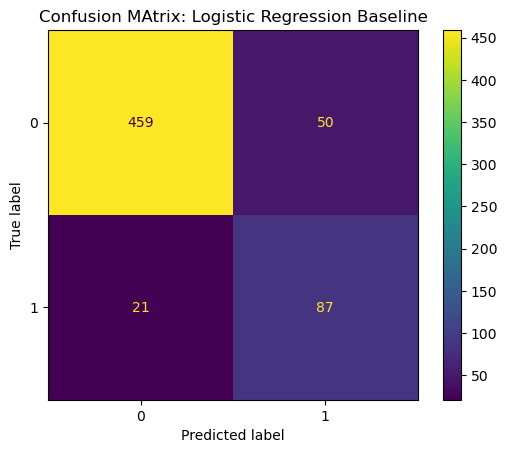

In [11]:
log_reg_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

log_reg_baseline_results = evaluate_model_cv(
    "Logistic Regression Baseline",
    log_reg_baseline,
    X_model,
    y,
    cv
)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Logistic Regression parameters:
{'model__C': 0.1, 'model__penalty': 'l1'}
Best CV Balanced Log loss: 0.39358194630331783
Tuned Logistic Regression
Accuracy: 0.8687
Log Loss: 0.4050
Balanced Log Loss: 0.3939

Classifciation Report
              precision    recall  f1-score   support

           0       0.96      0.88      0.92       509
           1       0.59      0.81      0.68       108

    accuracy                           0.87       617
   macro avg       0.77      0.84      0.80       617
weighted avg       0.89      0.87      0.88       617



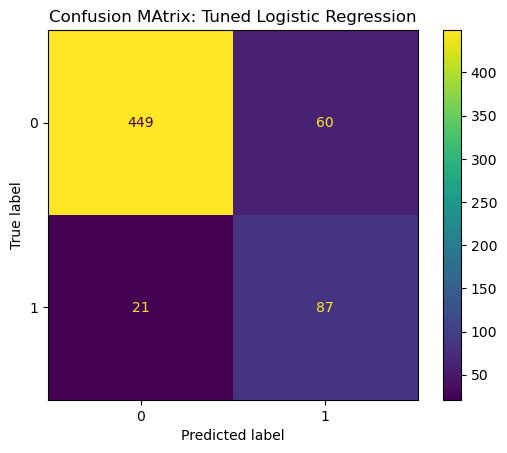

In [12]:
#LogReg model

log_reg_tune = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])

if FAST_MODE:
    log_reg_param_grid = {
        "model__C": [0.01, 0.1, 1],
        "model__penalty": ["l1", "l2"]
    }
else:
    log_reg_param_grid = {
        "model__C": [0.001, 0.01, 0.1, 1, 10],
        "model__penalty": ["l1", "l2"]
    }

log_reg_grid = GridSearchCV(
    estimator=log_reg_tune,
    param_grid=log_reg_param_grid,
    scoring=negative_balanced_log_loss_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

log_reg_grid.fit(X_model, y)

print("Best Logistic Regression parameters:")
print(log_reg_grid.best_params_)
print("Best CV Balanced Log loss:", -log_reg_grid.best_score_)

best_log_reg = log_reg_grid.best_estimator_

log_reg_tuned_results = evaluate_model_cv(
    "Tuned Logistic Regression",
    best_log_reg,
    X_model,
    y,
    cv
)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Linear SVM Parameters:
{'model__C': 0.01}
Best CV Balanced Log Loss: 0.5978003775363694
Tuned Linear SVM
Accuracy: 0.8898
Log Loss: 0.3218
Balanced Log Loss: 0.6001

Classifciation Report
              precision    recall  f1-score   support

           0       0.90      0.97      0.94       509
           1       0.78      0.52      0.62       108

    accuracy                           0.89       617
   macro avg       0.84      0.74      0.78       617
weighted avg       0.88      0.89      0.88       617



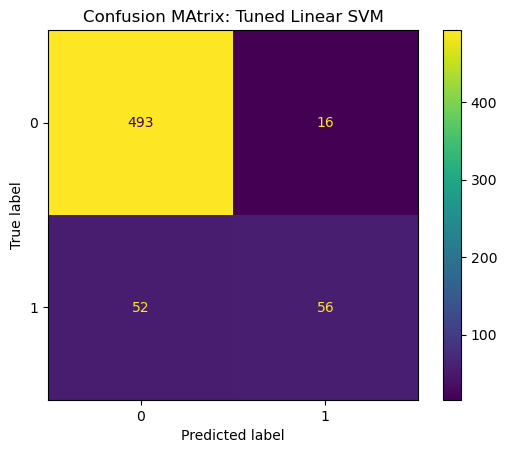

In [13]:
#Linear SVM model
linear_svm = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(
        kernel="linear",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

if FAST_MODE:
    linear_svm_param_grid = {
        "model__C": [0.01, 0.1, 1]
    }
else:
    linear_svm_param_grid = {
        "model__C": [0.001, 0.01, 0.1, 1, 10]
    }  

linear_svm_grid = GridSearchCV(
    estimator=linear_svm,
    param_grid=linear_svm_param_grid,
    scoring=negative_balanced_log_loss_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

linear_svm_grid.fit(X_model, y)

print("Best Linear SVM Parameters:")
print(linear_svm_grid.best_params_)
print("Best CV Balanced Log Loss:", -linear_svm_grid.best_score_)

best_linear_svm = linear_svm_grid.best_estimator_

linear_svm_results = evaluate_model_cv(
    "Tuned Linear SVM",
    best_linear_svm,
    X_model,
    y,
    cv
)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best RBF SVM Parameters:
{'model__C': 10, 'model__gamma': 'scale'}
Best CV Balanced Log Loss: 0.44135094538252995
Tuned RBF SVM
Accuracy: 0.8995
Log Loss: 0.2355
Balanced Log Loss: 0.4425

Classifciation Report
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       509
           1       0.79      0.58      0.67       108

    accuracy                           0.90       617
   macro avg       0.85      0.77      0.81       617
weighted avg       0.89      0.90      0.89       617



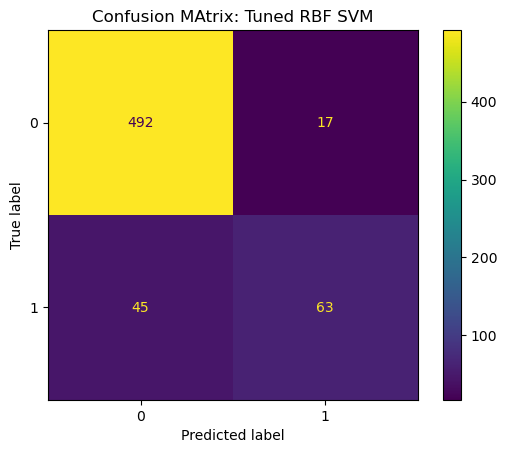

In [14]:
#RBF MODEL

rbf_svm = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

if FAST_MODE:
    rbf_svm_param_grid = {
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", 0.01]
    }
else:
    rbf_svm_param_grid = {
        "model__C": [0.1, 1, 10, 50],
        "model__gamma": ["scale", 0.001, 0.01, 0.1]
    }  

rbf_svm_grid = GridSearchCV(
    estimator=rbf_svm,
    param_grid=rbf_svm_param_grid,
    scoring=negative_balanced_log_loss_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rbf_svm_grid.fit(X_model, y)

print("Best RBF SVM Parameters:")
print(rbf_svm_grid.best_params_)
print("Best CV Balanced Log Loss:", -rbf_svm_grid.best_score_)

best_rbf_svm = rbf_svm_grid.best_estimator_

rbf_svm_results = evaluate_model_cv(
    "Tuned RBF SVM",
    best_rbf_svm,
    X_model,
    y,
    cv
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Random Forest Parameters:
{'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV Balanced Log Loss: 0.4174970378066537
Tuned Random Forest
Accuracy: 0.9335
Log Loss: 0.2768
Balanced Log Loss: 0.4174

Classifciation Report
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       509
           1       0.84      0.77      0.80       108

    accuracy                           0.93       617
   macro avg       0.90      0.87      0.88       617
weighted avg       0.93      0.93      0.93       617



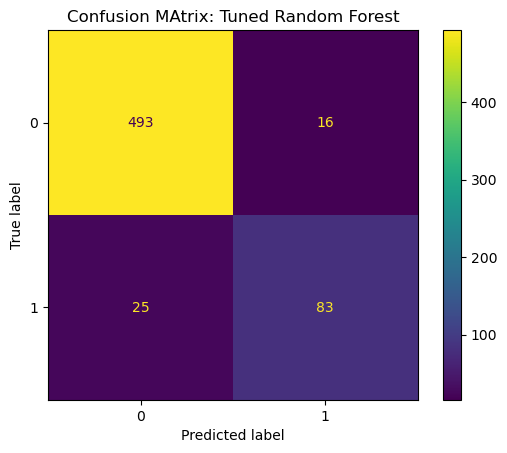

In [15]:
#Random Forest Model

random_forest = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

if FAST_MODE:
    rf_param_grid = {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 5, 8],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
        "model__max_features": ["sqrt"]
    }
else:
    rf_param_grid = {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [None, 3, 5, 8, 12],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2"]
    }

rf_grid = GridSearchCV(
    estimator=random_forest,
    param_grid=rf_param_grid,
    scoring=negative_balanced_log_loss_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_model, y)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)
print("Best CV Balanced Log Loss:", -rf_grid.best_score_)

best_rf = rf_grid.best_estimator_

rf_results = evaluate_model_cv(
    "Tuned Random Forest",
    best_rf,
    X_model,
    y,
    cv
)

In [16]:
#Comparison with Balanced Log loss

all_results = [
    log_reg_baseline_results,
    log_reg_tuned_results,
    linear_svm_results,
    rbf_svm_results,
    rf_results
]

comparison_df = pd.DataFrame([
    {
        "Model": result["model_name"],
        "Accuracy": result["accuracy"],
        "Log Loss": result["log_loss"],
        "Balanced Log Loss": result["balanced_log_loss"]
    }
    for result in all_results
]).sort_values("Balanced Log Loss")

comparison_df

,Model,Accuracy,Log Loss,Balanced Log Loss
1,Tuned Logistic Regression,0.868720,0.405039,0.393925
4,Tuned Random Forest,0.933549,0.276801,0.417403
3,Tuned RBF SVM,0.899514,0.235492,0.442527
2,Tuned Linear SVM,0.889789,0.321816,0.600091
0,Logistic Regression Baseline,0.884927,0.430689,0.621491


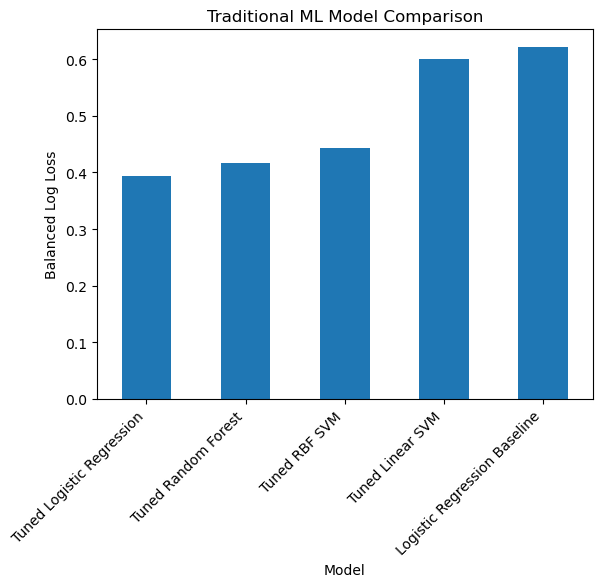

In [17]:
comparison_df.set_index("Model")["Balanced Log Loss"].sort_values().plot(kind="bar")
plt.title("Traditional ML Model Comparison")
plt.ylabel("Balanced Log Loss")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.show()

In [18]:
#Selelcts the Lowest loss model with is the best for this

model_lookup = {
    "Logistic Regression Baseline": log_reg_baseline,
    "Tuned Logistic Regression": best_log_reg,
    "Tuned Linear SVM": best_linear_svm,
    "Tuned RBF SVM": best_rbf_svm,
    "Tuned Random Forest": best_rf
}

best_model_name = comparison_df.iloc[0]["Model"]
best_model = model_lookup[best_model_name]

print("Best Traditional ML Model:", best_model_name)
print(comparison_df.iloc[0])

Best Traditional ML Model: Tuned Logistic Regression
Model                Tuned Logistic Regression
Accuracy                               0.86872
Log Loss                              0.405039
Balanced Log Loss                     0.393925
Name: 1, dtype: object


In [19]:
#Predictos probabilites for the test set
ensemble_oof = pd.DataFrame({
    "Id": train["Id"],
    "Class": y
})

for result in all_results:
    name = result["model_name"].replace(" ","_").replace("-","_").lower()
    ensemble_oof[f"{name}_class_0"] = result["oof_proba"][:, 0]
    ensemble_oof[f"{name}_class_1"] = result["oof_proba"][:, 1]

ensemble_oof.to_csv("traditional_oof_predictions.csv", index=False)

ensemble_oof.head()

,Id,Class,logistic_regression_baseline_class_0,logistic_regression_baseline_class_1,tuned_logistic_regression_class_0,tuned_logistic_regression_class_1,tuned_linear_svm_class_0,tuned_linear_svm_class_1,tuned_rbf_svm_class_0,tuned_rbf_svm_class_1,tuned_random_forest_class_0,tuned_random_forest_class_1
0,000ff2bfdfe9,1,0.041724,0.958276,0.155504,0.844496,0.439395,0.560605,0.322761,0.677239,0.373611,0.626389
1,007255e47698,0,0.998422,0.001578,0.952705,0.047295,0.983845,0.016155,0.997515,0.002485,0.919171,0.080829
2,013f2bd269f5,0,0.849583,0.150417,0.557492,0.442508,0.775494,0.224506,0.970591,0.029409,0.703381,0.296619
3,043ac50845d5,0,0.968952,0.031048,0.644319,0.355681,0.933624,0.066376,0.987697,0.012303,0.716528,0.283472
4,044fb8a146ec,1,0.024419,0.975581,0.410677,0.589323,0.500000,0.500000,0.467941,0.532059,0.589872,0.410128


In [20]:


best_model.fit(X_model, y)

test_proba = best_model.predict_proba(test_model)

traditional_test_predictions = pd.DataFrame({
    "Id": test_ids,
    "class_0": test_proba[:, 0],
    "class_1": test_proba[:, 1]
})

traditional_test_predictions.to_csv("traditional_test_predictions.csv", index=False)

traditional_test_predictions

,Id,class_0,class_1
0,00eed32682bb,0.449523,0.550477
1,010ebe33f668,0.449523,0.550477
2,02fa521e1838,0.449523,0.550477
3,040e15f562a2,0.449523,0.550477
4,046e85c7cc7f,0.449523,0.550477


In [21]:
#Kaggle Submission File
submission = pd.DataFrame({
    "Id": test_ids,
    "class_0": test_proba[:, 0],
    "class_1": test_proba[:, 1]
})

submission["prob_sum"] = submission["class_0"] + submission["class_1"]
print(submission["prob_sum"])

submission = submission.drop(columns=["prob_sum"])

submission.to_csv("submission_traditional_ml.csv", index=False)

submission.head()

0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: prob_sum, dtype: float64


,Id,class_0,class_1
0,00eed32682bb,0.449523,0.550477
1,010ebe33f668,0.449523,0.550477
2,02fa521e1838,0.449523,0.550477
3,040e15f562a2,0.449523,0.550477
4,046e85c7cc7f,0.449523,0.550477
